In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

In [4]:
print(type(x_train))
print(type(y_train))

print("Train samples:", len(x_train))
print("Test samples:", len(x_test))

print("First review:")
print(x_train[0])

print("First label:")
print(y_train[0])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Train samples: 25000
Test samples: 25000
First review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472

In [5]:
print(x_train[0])
print(y_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1


In [6]:
review_lengths=[len(review) for review in x_train]
print("Shortest review:", min(review_lengths))
print("Longest review:", max(review_lengths))
print("Average review length:", np.mean(review_lengths))
print("Median review length:", np.median(review_lengths))


Shortest review: 11
Longest review: 2494
Average review length: 238.71364
Median review length: 178.0


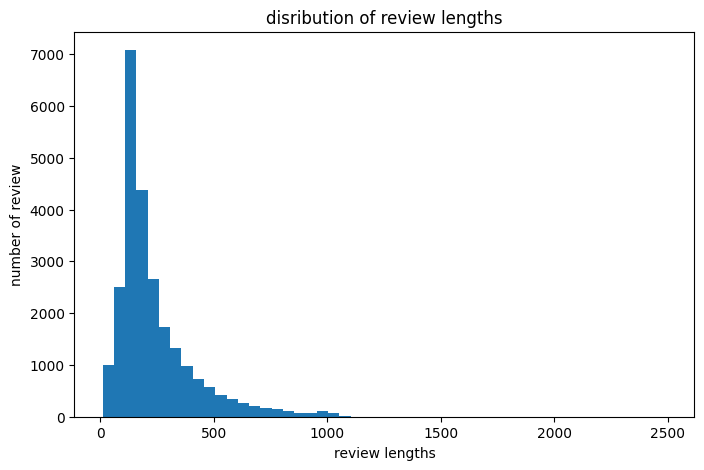

In [7]:
plt.figure(figsize=(8,5))
plt.hist(review_lengths,bins=50)
plt.xlabel("review lengths")
plt.ylabel("number of review")
plt.title("disribution of review lengths")
plt.show()

1    12500
0    12500
Name: count, dtype: int64


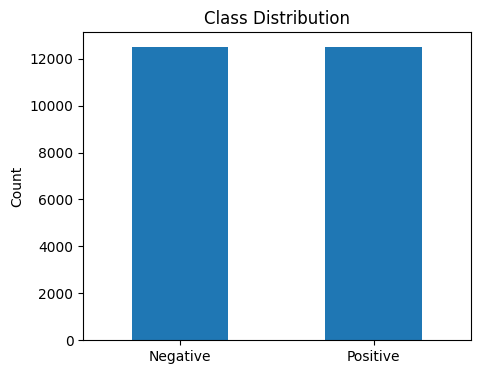

In [8]:
label_count=pd.Series(y_train).value_counts()
print(label_count)
plt.figure(figsize=(5, 4))
label_count.plot(kind="bar")
plt.xticks([0, 1], ["Negative", "Positive"], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()


In [9]:

word_index = imdb.get_word_index()

reverse_word_index = {value: key for key, value in word_index.items()}

decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in x_train[0]]
)

print(decoded_review)
print("Label:", y_train[0])

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [10]:
max_length = 200

x_train_padded = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test_padded = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [11]:
print("Before padding:", len(x_train[0]))
print("After padding:", len(x_train_padded[0]))

print("Train shape:", x_train_padded.shape)
print("Test shape:", x_test_padded.shape)

Before padding: 218
After padding: 200
Train shape: (25000, 200)
Test shape: (25000, 200)


In [12]:
print("Average review length:", np.mean(review_lengths))
print(label_count)
print("Train shape:", x_train_padded.shape)

Average review length: 238.71364
1    12500
0    12500
Name: count, dtype: int64
Train shape: (25000, 200)


In [13]:
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    LayerNormalization,
    Dense,
    Dropout,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [14]:
inputs = Input(shape=(max_length,))

embedding = Embedding(
    input_dim=vocab_size,
    output_dim=64
)(inputs)

attention_output = MultiHeadAttention(
    num_heads=2,
    key_dim=64
)(embedding, embedding)

attention_output = Dropout(0.2)(attention_output)

x = LayerNormalization()(embedding + attention_output)

dense_output = Dense(64, activation="relu")(x)

dense_output = Dropout(0.2)(dense_output)

x = LayerNormalization()(x + dense_output)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)

x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs=inputs, outputs=outputs)

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 64)   │    640,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 64)   │     33,216 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 200, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 64)   │          0 │ embedding[0][0],  │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 200, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 200, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 200, 64)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 200, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 681,857 (2.60 MB)

 Trainable params: 681,857 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    x_train_padded,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 257ms/step - accuracy: 0.8018 - loss: 0.4119 - val_accuracy: 0.8710 - val_loss: 0.3231
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 159s 254ms/step - accuracy: 0.9086 - loss: 0.2366 - val_accuracy: 0.8742 - val_loss: 0.3353
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 160s 255ms/step - accuracy: 0.9365 - loss: 0.1744 - val_accuracy: 0.8626 - val_loss: 0.3510


In [17]:
test_loss, test_accuracy = model.evaluate(x_test_padded, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.8599 - loss: 0.3346
Test Loss: 0.3345552980899811
Test Accuracy: 0.8599200248718262


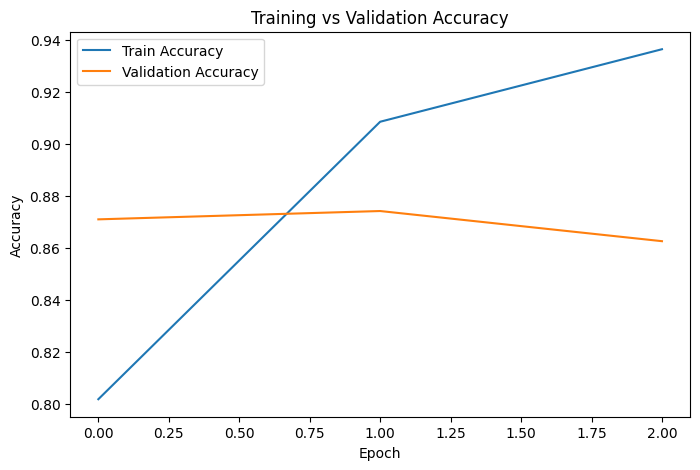

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

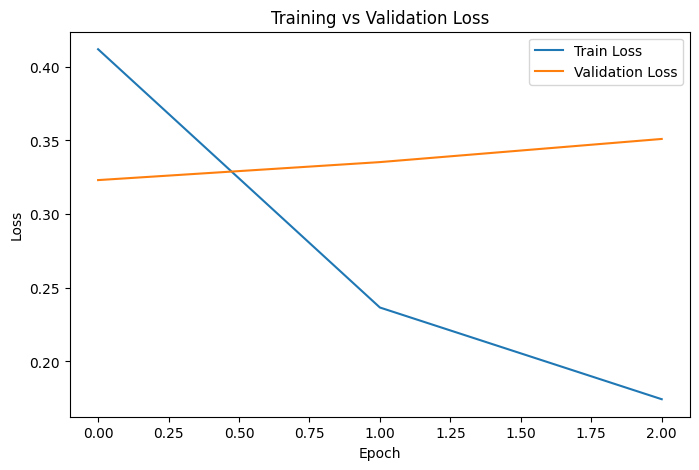

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [20]:
model.save("imdb_transformer_model.keras")

In [30]:
from tensorflow.keras.models import load_model

loaded_model = load_model("imdb_transformer_model.keras")
word_index = imdb.get_word_index()

text = "this movie was amazing and I really loved the story"

words = text.lower().split()

encoded_text = []

for word in words:
    index = word_index.get(word)

    if index is not None and index < vocab_size:
        encoded_text.append(index + 3)
    else:
        encoded_text.append(2)

print(encoded_text)

padded_text = pad_sequences(
    [encoded_text],
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print(padded_text.shape)

prediction = loaded_model.predict(padded_text)

print(prediction)

[14, 20, 16, 480, 5, 13, 66, 447, 4, 65]
(1, 200)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
[[0.9986016]]


In [31]:
score = prediction[0][0]

if score >= 0.5:
    print("Positive review")
else:
    print("Negative review")

print("Score:", score)

Positive review
Score: 0.9986016
